[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/spirosChv/neuro208-tutorials/blob/main/Practical_NEURON_and_DendroTweaks/NEURON_tutorial_1.ipynb)

# NEURON: The basics

In [ ]:
!pip install neuron --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 36.7 MB/s eta 0:00:00


In [ ]:
import neuron
from neuron import h # stands for hoc

## 1. Morphology

Topology

In [ ]:
soma = h.Section(name='soma')
dend = h.Section(name='dend')
dend.connect(soma, 0.5) # select a section and a relative position in [0, 1] along that section

dend

In [ ]:
dend.parentseg()

soma(0.5)

In [ ]:
h.topology()


|-|       soma(0-1)
  `|       dend(0-1)



1.0

### Geometry

In [ ]:
soma.L = 20 # length in um
soma.diam = 20 # diameter in um

In [ ]:
# Set dendritic length to 200 um and diameter to 1 um
dend.L = 200
dend.diam = 1

## 2. Biophysics

### Passive properties

In [ ]:
soma.cm = 1 # specific membrane capacitance in uF/cm**2
soma.Ra = 100 # axial resistance in Ohm*cm

In [ ]:
# Set dendritic specific membrane capacitance to 1 um and axial resistance to 100 MOhm
dend.cm = 1
dend.Ra = 100

### Segmentation

In [ ]:
print(soma.nseg, dend.nseg) # by default all sections have one segment

1 1


In [ ]:
dend.nseg = 5 # we can manually set the number of segments

In [ ]:
segments = [seg for seg in dend] # we can list all the segments in a given section
print(segments)

[dend(0.1), dend(0.3), dend(0.5), dend(0.7), dend(0.9)]


In [ ]:
dend(0.7) # we can access segments by calling a section with an argument in [0, 1]

dend(0.7)

In [ ]:
dend(0.7).sec # each segment has a reference to its section

dend

### Membrane mechanism

In [ ]:
soma.insert('pas') # leak (potassium) channel, always open
dend.insert('pas')

dend

In [ ]:
print(soma.psection())

{'point_processes': {}, 'density_mechs': {'pas': {'g': [0.001], 'e': [-70.0], 'i': [0.0]}}, 'ions': {}, 'morphology': {'L': 20.0, 'diam': [20.0], 'pts3d': [], 'parent': None, 'trueparent': None}, 'nseg': 1, 'Ra': 100.0, 'cm': [1.0], 'regions': set(), 'species': set(), 'name': 'soma', 'hoc_internal_name': '__nrnsec_0x40e63130', 'cell': None}


In [ ]:
print(soma.psection()['density_mechs']['pas'])

{'g': [0.001], 'e': [-70.0], 'i': [0.0]}


## 3. Stimuli

### Step current injection

In [ ]:
iclamp = h.IClamp(soma(0.5)) # we select a segment where we want to inject current
iclamp.amp = 0.5 # amplitude in nA
iclamp.dur = 80 # duration in ms
iclamp.delay = 10 # onset delay in ms

## 4. Running a simulation

### Recordings

In [ ]:
t = h.Vector().record(h._ref_t) # a vector that records time
v = h.Vector().record(soma(0.5)._ref_v) # a vector that records voltage

### Simulation

In [ ]:
h.load_file('stdrun.hoc')

1.0

In [ ]:
h.finitialize(-70) # initialize all segments at -70 mV
h.continuerun(100) # run simulation for 100 ms

0.0

### Plotting the results

Text(0, 0.5, 'Voltage (mV)')

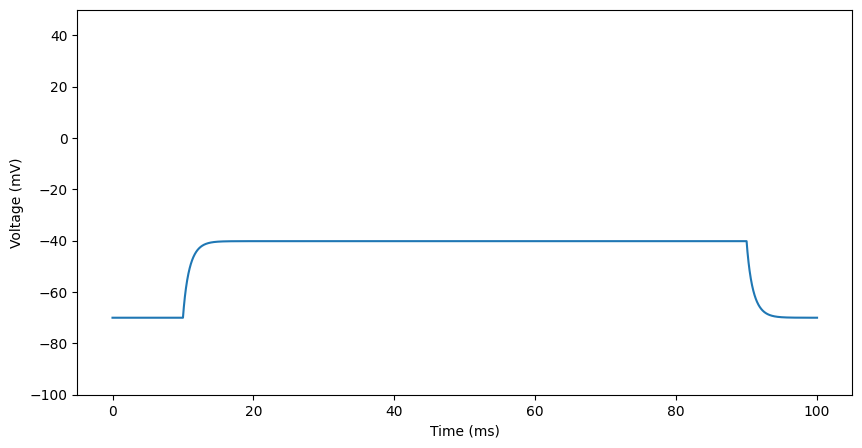

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, v)
ax.set_ylim(-100, 50)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')